/home/users/grad/2025/25t0024/miniconda3/envs/kuzushiji/lib/python3.12/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Using device: cuda


/tmp/ipykernel_1721068/326389819.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


チェックポイントを読み込みました（エポック 94）
学習を開始します...
start epcoch


Epoch 95/100 [Test]: 100%|█████████████████████████████████████████████| 940/940 [34:34<00:00,  2.21s/it, loss=0.000256]


...

Epoch 98/100 | Train Loss: 0.0003 | Test Loss: 0.0004
start epcoch


Epoch 99/100 [Test]: 100%|█████████████████████████████████████████████| 940/940 [16:09<00:00,  1.03s/it, loss=0.000172]


Epoch 99/100 | Train Loss: 0.0003 | Test Loss: 0.0004
start epcoch


Epoch 100/100 [Test]: 100%|████████████████████████████████████████████| 940/940 [12:22<00:00,  1.27it/s, loss=0.000295]


Epoch 100/100 | Train Loss: 0.0003 | Test Loss: 0.0004
学習が完了しました。


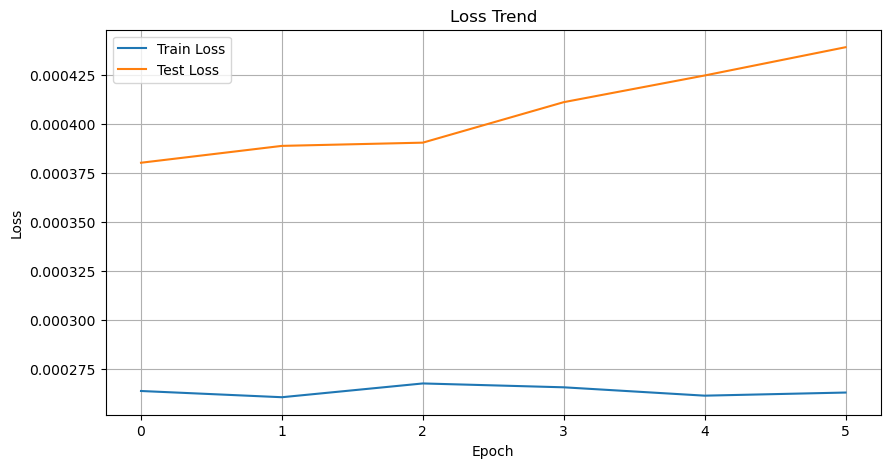

In [1]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from src.my_app import UNet, create_optimized_dataloader
from src.my_app.core.MyDataset import PreTrainDataset_v2
import torch
from PIL import Image
import torchvision.transforms as transforms
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import os
import json
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import multiprocessing as mp


def crop_labels_to_match(labels_to_crop, target_tensor):
    target_h, target_w = target_tensor.shape[2:]
    source_h, source_w = labels_to_crop.shape[2:]
    delta_h = (source_h - target_h) // 2
    delta_w = (source_w - target_w) // 2
    return labels_to_crop[:, :, delta_h:delta_h + target_h, delta_w:delta_w + target_w]
transform = transforms.Compose([
    # transforms.Resizeze((128, 128)),
    transforms.ToTensor()
])
# --- Dataset ---
test_doc_id_list = [
    '200021637',
    '100249371',
    '100249537',
    '200005598',
    '200014740',
    '200020019',
    '200021712',
    '200021869'
]
train_dataset = PreTrainDataset_v2(
    input_path='../../kuzushiji-recognition/synthetic_images/input_images/',
    json_path='../../kuzushiji-recognition/synthetic_images/gt_json.json',
    test_doc_id_list=test_doc_id_list,
    test_mode=False,
    # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    # precompute_gt=True,
    precompute_gt=False,
    transform=transform,
    # target_width=400  # 横幅を400ピクセルに固定
)

test_dataset = PreTrainDataset_v2(
    input_path='../../kuzushiji-recognition/synthetic_images/input_images/',
    json_path='../../kuzushiji-recognition/synthetic_images/gt_json.json',
    test_doc_id_list=test_doc_id_list,
    test_mode=True,
    # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    # precompute_gt=True,
    precompute_gt=False,
    transform=transform,
    # target_width=400  # 横幅を400ピクセルに固定
)


# # 最適化されたDataLoaderの作成
num_workers = 4   # Mac + CUDA/MPS 混在やデバッグ時は 0 推奨。高速化したければ >0 試行。
# 最適化されたDataLoaderの作成
train_dl = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(num_workers > 0),
    prefetch_factor=2 if num_workers > 0 else None
)
test_dl = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(num_workers > 0),
    prefetch_factor=2 if num_workers > 0 else None
)
# train_dl = create_optimized_dataloader(train_dataset, batch_size=1, num_workers=min(mp.cpu_count(), 4))
# test_dl = create_optimized_dataloader(test_dataset, batch_size=1, num_workers=min(mp.cpu_count(), 4))

# --- モデル、損失関数、最適化手法の定義 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# device = torch.device("mps" if torch.cuda.is_available() else "cpu")
model = UNet(3, 4).to(device)
criterion = nn.MSELoss() # 回帰問題なのでMSE損失を使用
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- チェックポイントの設定 ---
checkpoint_dir = "../.checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# 最良のモデルを追跡するための変数
best_test_loss = float('inf')
start_epoch = 0

# チェックポイントの読み込み（存在する場合）
checkpoint_path = os.path.join(checkpoint_dir, "latest_checkpoint_v2.pth")
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    best_test_loss = checkpoint['best_test_loss']
    train_loss_history = checkpoint['train_loss_history']
    test_loss_history = checkpoint['test_loss_history']
    print(f"チェックポイントを読み込みました（エポック {start_epoch}）")

num_epochs = 100 # エポック数を定義

# 損失の履歴を保存するリストを初期化
train_loss_history = []
test_loss_history = []

print("学習を開始します...")
for epoch in range(start_epoch, num_epochs):
    print(f'start epcoch')
    # --- 訓練フェーズ ---
    model.train() # モデルを訓練モードに設定
    train_loss_total = 0
    
    # tqdmでプログレスバーを表示
    train_bar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")    
    for batch in train_bar:
        # バッチは (imgs, masks, file_id) 想定
        if len(batch) == 3:
            imgs, masks, file_ids = batch
        elif len(batch) == 2:
            imgs, masks = batch
            file_ids = None
        else:
            raise ValueError(f"Unexpected batch structure len={len(batch)}")
        imgs, masks = imgs.to(device), masks.to(device)
        
        preds = model(imgs)
        cropped_masks = crop_labels_to_match(masks, preds)

        loss = criterion(preds, cropped_masks)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss_total += loss.item()
        # プログレスバーに現在のロスを表示
        train_bar.set_postfix(loss=loss.item())

    avg_train_loss = train_loss_total / len(train_dl)
    train_loss_history.append(avg_train_loss)

    # --- 評価フェーズ ---
    model.eval() # モデルを評価モードに設定
    test_loss_total = 0
    
    # 勾配計算を無効化して、メモリ効率を良くする
    with torch.no_grad():
        test_bar = tqdm(test_dl, desc=f"Epoch {epoch+1}/{num_epochs} [Test]")
        for batch in test_bar:
            # バッチは (imgs, masks, file_id) 想定
            if len(batch) == 3:
                imgs, masks, file_ids = batch
            elif len(batch) == 2:
                imgs, masks = batch
                file_ids = None
            else:
                raise ValueError(f"Unexpected batch structure len={len(batch)}")
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            cropped_masks = crop_labels_to_match(masks, preds)
            
            loss = criterion(preds, cropped_masks)
            test_loss_total += loss.item()
            test_bar.set_postfix(loss=loss.item())

    avg_test_loss = test_loss_total / len(test_dl)
    test_loss_history.append(avg_test_loss)
    
    # 各エポックの最後に訓練ロスとテストロスを表示
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")
    
    # 最新のチェックポイントを保存
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss_history': train_loss_history,
        'test_loss_history': test_loss_history,
        'best_test_loss': best_test_loss
    }, os.path.join(checkpoint_dir, "latest_checkpoint_v2.pth"))
    
    # より良い性能が出た場合、ベストモデルとして保存
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'test_loss': avg_test_loss,
        }, os.path.join(checkpoint_dir, "best_model.pth"))
        print(f"新しいベストモデルを保存しました（Test Loss: {avg_test_loss:.4f}）")

print("学習が完了しました。")

# --- 損失の推移をグラフで表示 ---
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label="Train Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.title("Loss Trend")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()